**FASE 0: QC y EDA**

No es necesario un control de calidad exhaustivo pues los datos ya están normalizados, corregidos y listos para usarse. Sin embargo, en este cuaderno se inspeccionan antes de transformarlos, para comprobar y ver con qué se trabaja. En el dataset original, un sujeto fue descartado por artefactos que no ser podían eliminar. 

Es importante este paso precio de verificación pues el RSE compara matrices de disimilitud (RDMs) entre el cerebro y el modelo. Es muy sensible al ruido, y si un sujeto tiene una señal ruidosa el RDM será aleatorio, diluyendo así las correlaciones al promediar resultados entre sujetos.

**5.2 Estructura de los datos**

In [3]:
import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

DATA_DIR = r'C:\Users\Ale'  
TR = 2.0                                  # segundos por escaneo

In [4]:
# Tabla A — Estructura temporal por bloque (run)
mat         = sio.loadmat(f'{DATA_DIR}\\subject_1.mat', squeeze_me=True)
time_fmri   = mat['time'][:, 0]
runs        = mat['time'][:, 1].astype(int)
words       = mat['words']
word_starts = np.array([w['start'] for w in words])

# Cada palabra → su TR → su run
word_to_tr = np.clip(np.searchsorted(time_fmri, word_starts) - 1,
                     0, len(time_fmri) - 1)
word_runs  = runs[word_to_tr]

filas = []
for r in np.unique(runs):
    n_trs   = int((runs == r).sum())
    n_words = int((word_runs == r).sum())
    filas.append({'Bloque': r, 'TRs': n_trs, 'Duración (s)': n_trs * TR,
                  'Palabras': n_words, 'Palabras/TR': n_words / n_trs})

tabla_bloques = pd.DataFrame(filas).set_index('Bloque')
total = pd.DataFrame({'TRs': [tabla_bloques['TRs'].sum()],
                      'Duración (s)': [tabla_bloques['Duración (s)'].sum()],
                      'Palabras': [tabla_bloques['Palabras'].sum()],
                      'Palabras/TR': [tabla_bloques['Palabras'].sum() / tabla_bloques['TRs'].sum()]},
                     index=['TOTAL'])
tabla_bloques = pd.concat([tabla_bloques, total])
print(tabla_bloques.round(2).to_string())
tabla_bloques.to_csv('tabla_bloques.csv')

        TRs  Duración (s)  Palabras  Palabras/TR
1       340         680.0      1303         3.83
2       352         704.0      1351         3.84
3       279         558.0      1059         3.80
4       380         760.0      1463         3.85
TOTAL  1351        2702.0      5176         3.83


El capítulo se presentó dividido en cuatro bloques (*runs*), leídos de forma
consecutiva con descansos cortos entre ellos. Esta celda resume, para cada
bloque, el número de escaneos cerebrales (TRs), su duración en segundos, el
número de palabras leídas y la media de palabras por TR. Cada palabra se asigna
a su bloque a partir de su instante de inicio, comparándolo con el tiempo de
cada TR.

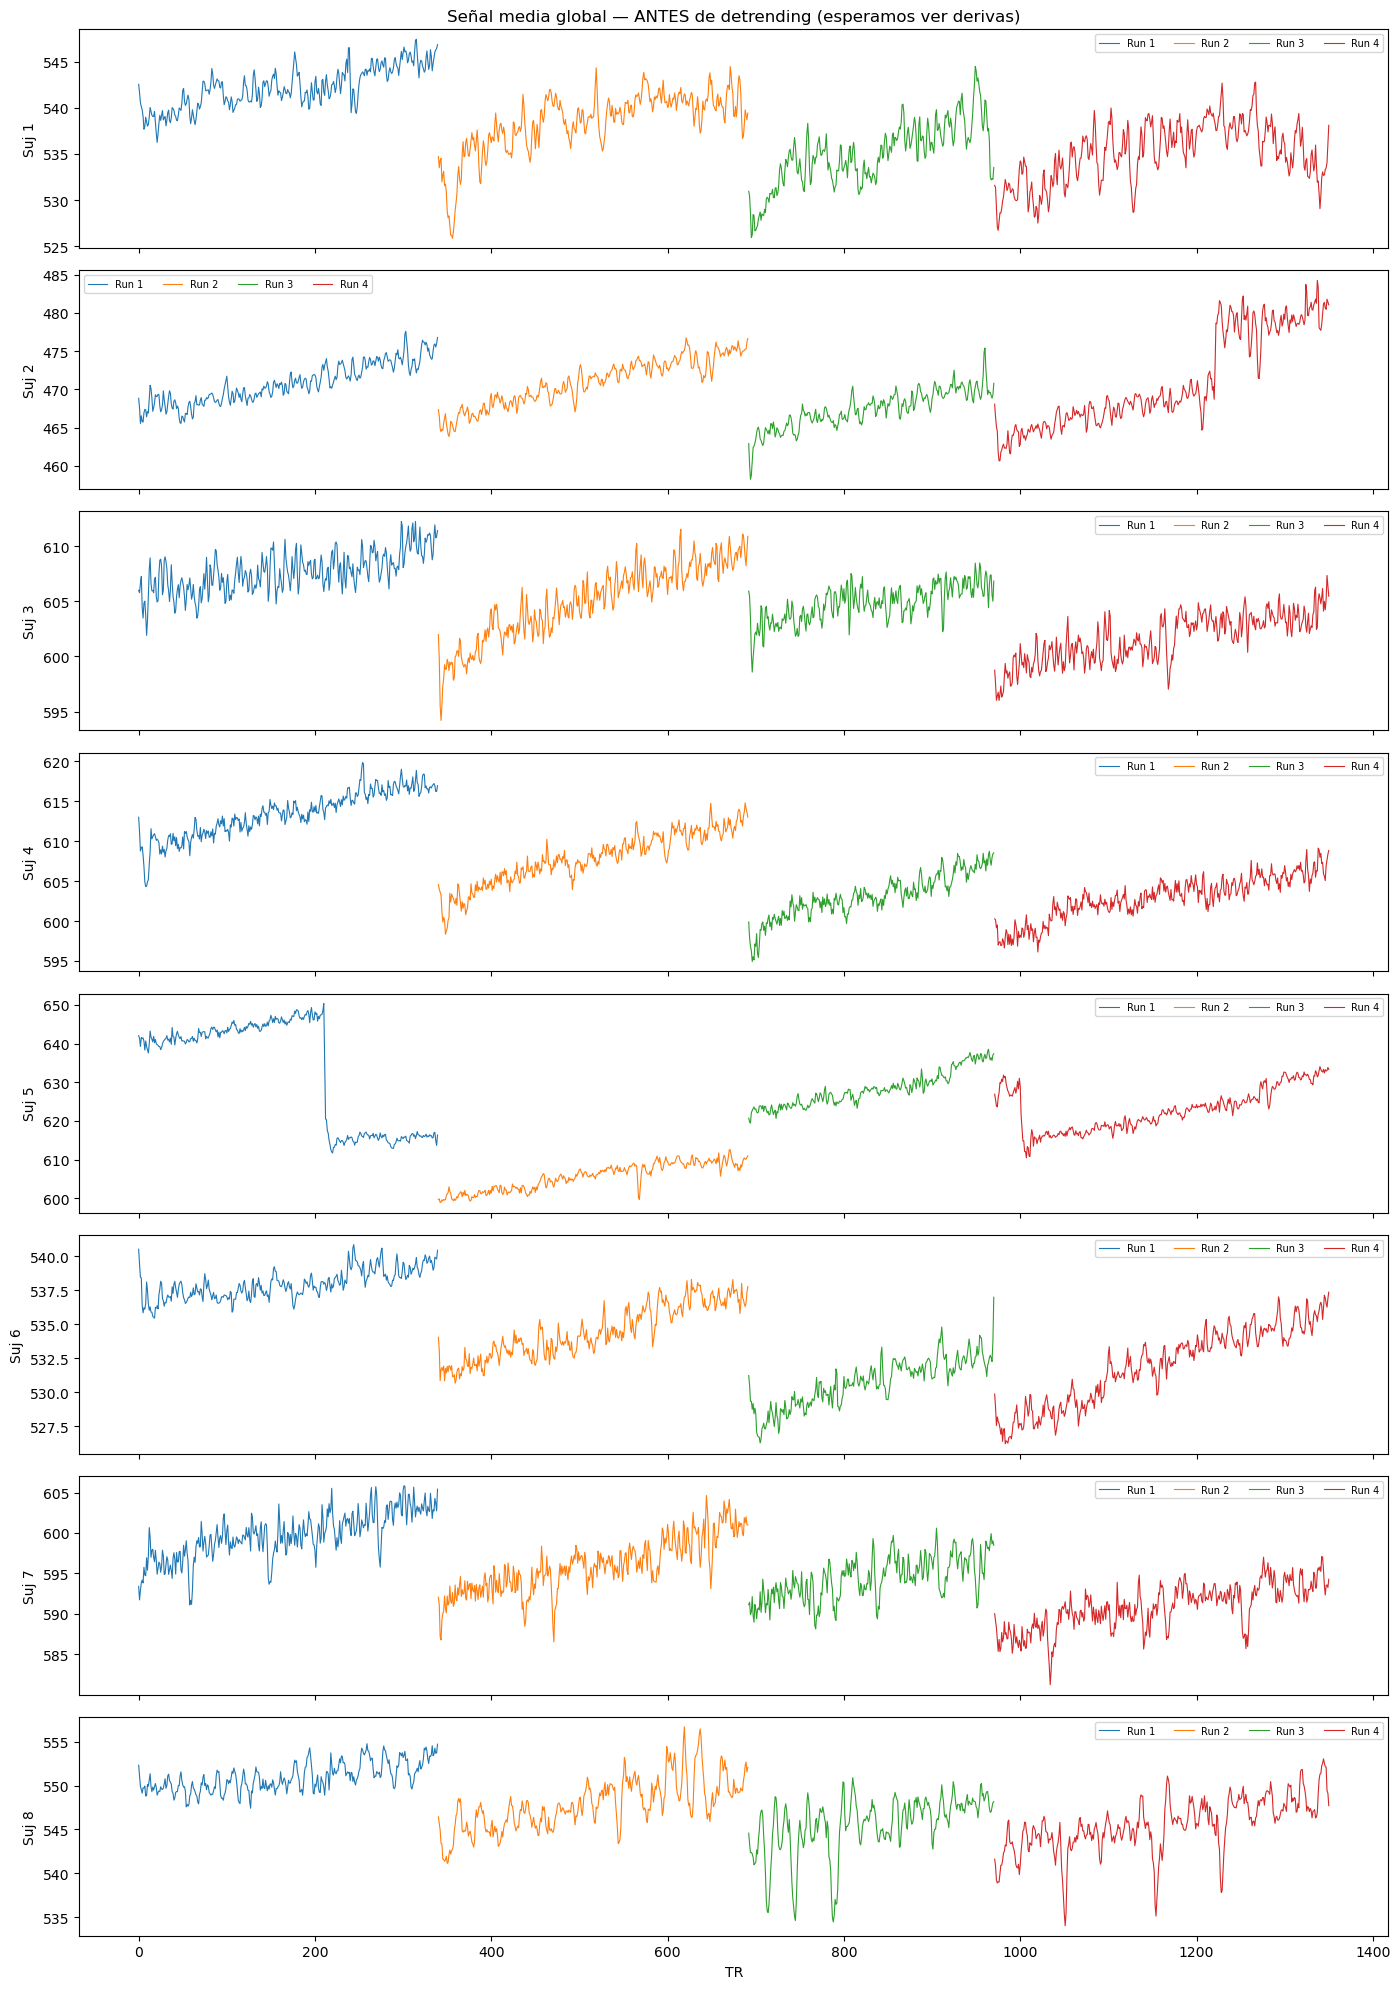

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(8, 1, figsize=(14, 20), sharex=True)

for idx, subj_id in enumerate(range(1, 9)):
    path = f'C:\\Users\\Ale\\Desktop\\TFM\\subject_{subj_id}.mat'
    mat = sio.loadmat(path, squeeze_me=True)
    data = mat['data']
    runs = mat['time'][:, 1].astype(int)

    ax = axes[idx]
    global_signal = data.mean(axis=1)

    for run_id in np.unique(runs):
        mask = runs == run_id
        trs = np.where(mask)[0]
        ax.plot(trs, global_signal[mask], label=f'Run {run_id}', lw=0.8)

    ax.set_ylabel(f'Suj {subj_id}')
    ax.legend(fontsize=7, ncol=4)

axes[-1].set_xlabel('TR')
axes[0].set_title('Señal media global — ANTES de detrending '
                   '(esperamos ver derivas)')
plt.tight_layout()
plt.savefig('qc_global_signal.png', dpi=150)
plt.show()

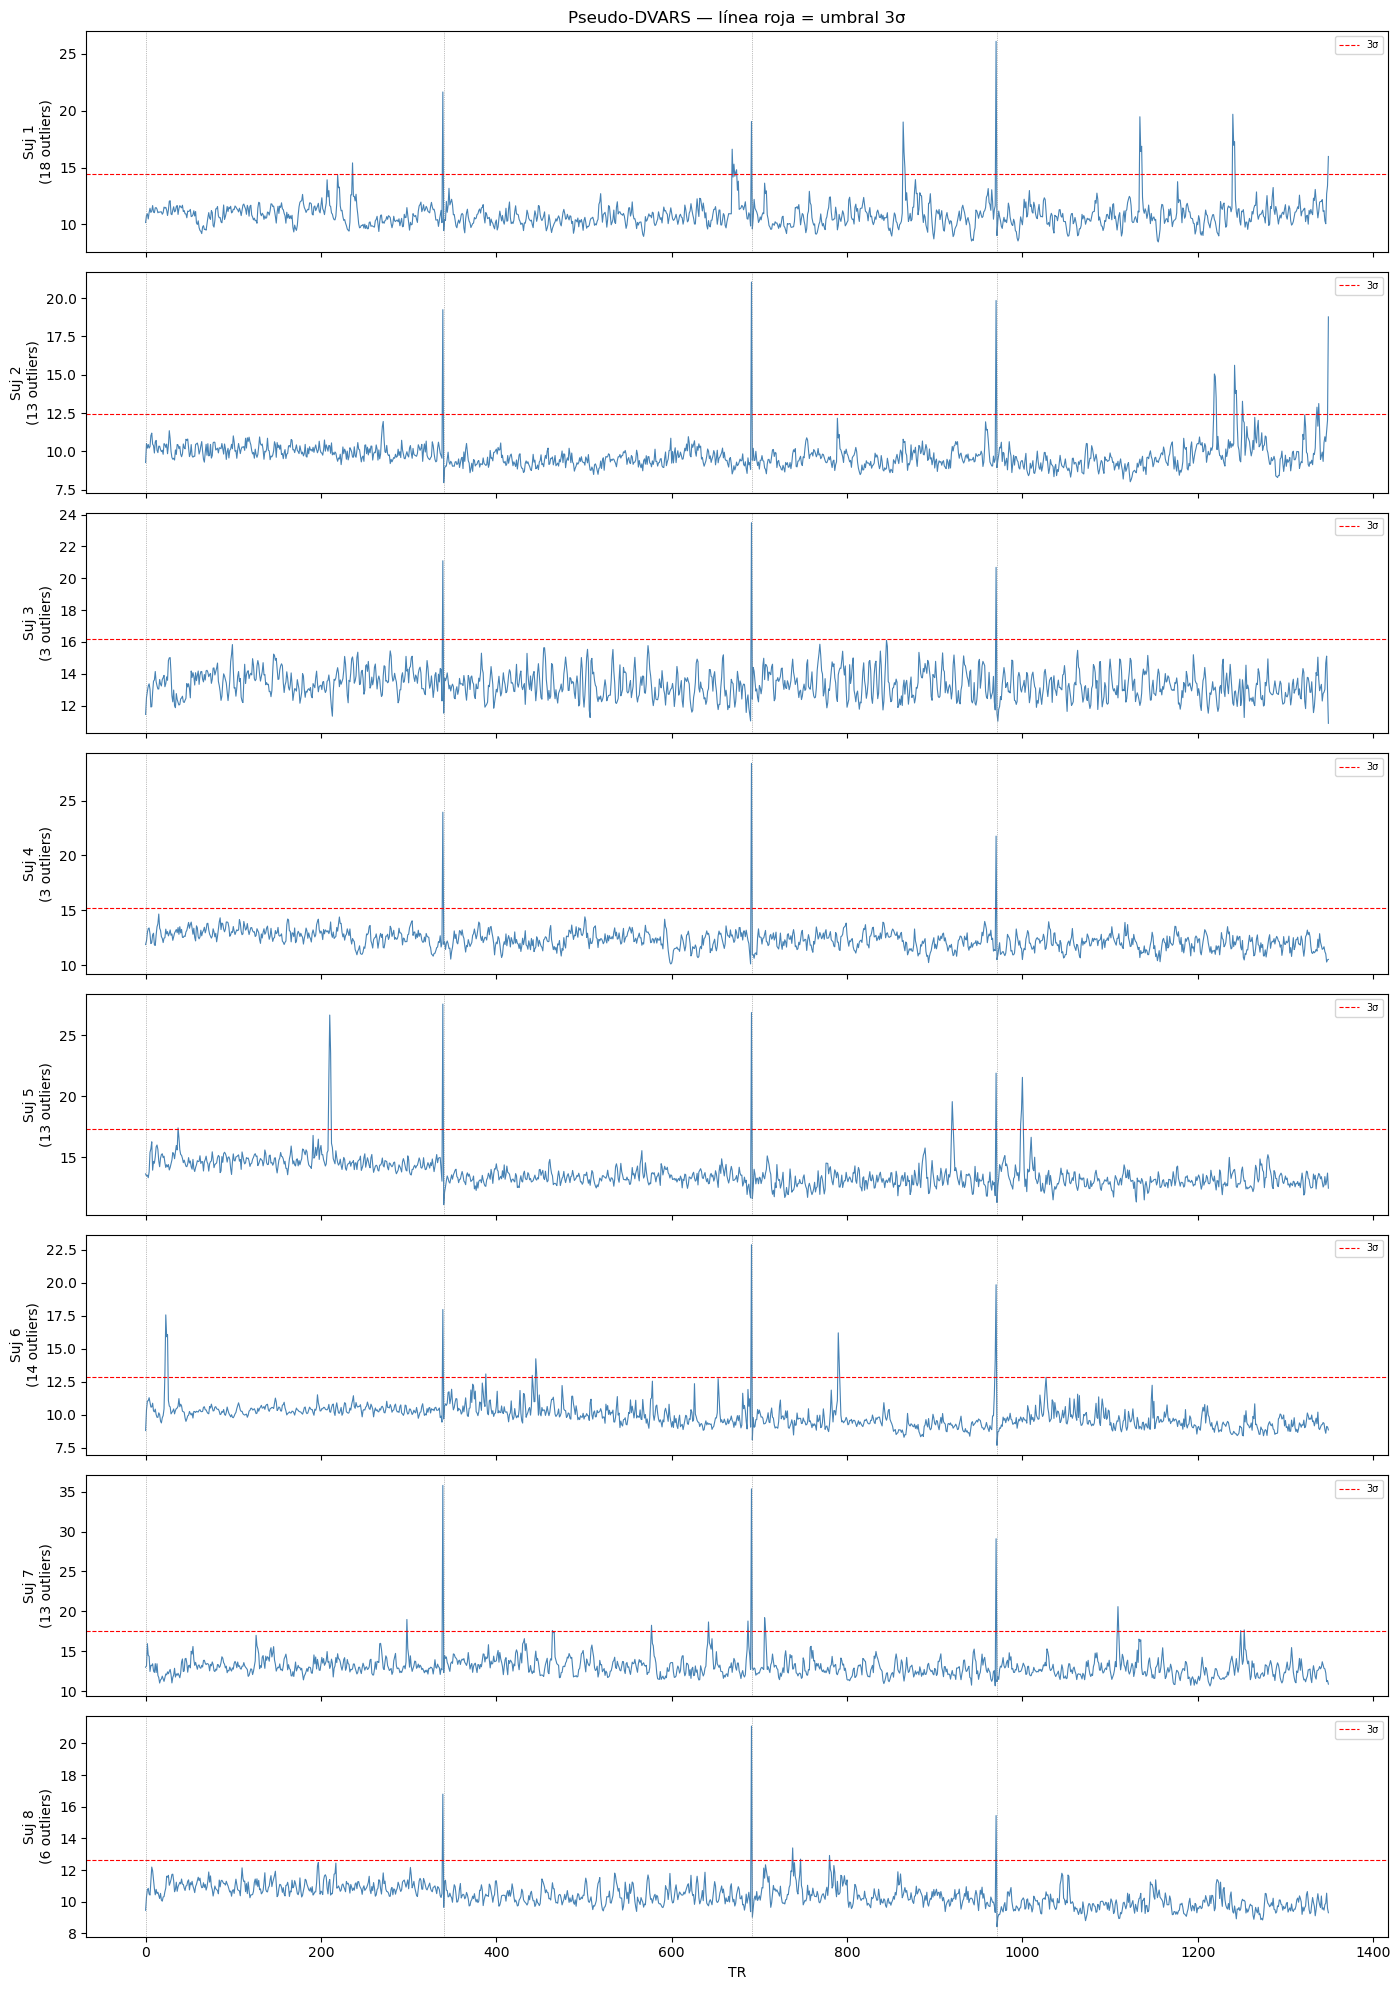

In [20]:
fig, axes = plt.subplots(8, 1, figsize=(14, 20), sharex=True)

for idx, subj_id in enumerate(range(1, 9)):
    path = f'C:\\Users\\Ale\\Desktop\\TFM\\subject_{subj_id}.mat'
    mat = sio.loadmat(path, squeeze_me=True)
    data = mat['data']
    runs = mat['time'][:, 1].astype(int)

    diff = np.diff(data, axis=0)
    pseudo_dvars = np.sqrt(np.mean(diff**2, axis=1))

    ax = axes[idx]
    ax.plot(pseudo_dvars, color='steelblue', lw=0.8)
    threshold = np.mean(pseudo_dvars) + 3 * np.std(pseudo_dvars)
    ax.axhline(threshold, color='red', ls='--', lw=0.8, label='3σ')

    # Marcar límites de runs
    for run_id in np.unique(runs):
        run_start = np.where(runs == run_id)[0][0]
        ax.axvline(run_start, color='gray', ls=':', lw=0.5)

    n_outliers = (pseudo_dvars > threshold).sum()
    ax.set_ylabel(f'Suj {subj_id}\n({n_outliers} outliers)')
    ax.legend(fontsize=7)

axes[0].set_title('Pseudo-DVARS — línea roja = umbral 3σ')
axes[-1].set_xlabel('TR')
plt.tight_layout()
plt.savefig('qc_pseudo_dvars.png', dpi=150)
plt.show()

La señal media global por run verifica que haya derivas en la misma, en forma de tendencias lentas, ascendentes o descendentes, que no se corresponden con actividad neuronal real. Esto se debe al calentamiento progresivo del escáner durante la sesión, pues resulta en una fluctuación de los niveles basales del CO2 del sujeto. 

Se miden los TR (tiempo en el eje x) frente a pseudo-DVARS, que miden la magnitud del cambio. Este cambio no debería superar la línea roja, pues es un umbral que indica que algo pasó entre un TR y el siguiente, por ejemplo que el sujeto moviera la cabeza. Los gráficos muestran que estos picos son escasos y aislados, y se concluye que la calidad global de la señal es adecuada.

Aspectos a corregir en el Notebook 1 correspondiente a la Fase 1 de preprocesamiento:
- El dataset original no tiene "detrending", por lo que se observan derivas. 
- Además, puesto que cada run tiene su propio baseline, se encuentran saltos abruptos entre runs, lo que verifica que cada run debe ser procesado por separado. 
- Finalmente, aparecen picos abruptos que pueden ser causa de artefactos de movimiento y por tanto ser outliers.

In [5]:
# Tabla B — Dimensiones y calidad de señal por sujeto
filas = []
for subj_id in range(1, 9):
    mat  = sio.loadmat(f'{DATA_DIR}\\subject_{subj_id}.mat', squeeze_me=True)
    data = mat['data']                                   # (nTRs, nVóxeles)

    tsnr  = data.mean(axis=0) / (data.std(axis=0) + 1e-10)
    dvars = np.sqrt(np.mean(np.diff(data, axis=0)**2, axis=1))
    n_out = int((dvars > dvars.mean() + 3 * dvars.std()).sum())

    filas.append({'Sujeto': subj_id, 'Vóxeles': data.shape[1], 'TRs': data.shape[0],
                  'tSNR mediano': np.median(tsnr), '% tSNR>20': (tsnr > 20).mean() * 100,
                  'Señal mín': data.min(), 'Señal máx': data.max(), 'Outliers mov.': n_out})

tabla_sujetos = pd.DataFrame(filas).set_index('Sujeto')
print(tabla_sujetos.round(1).to_string())
print('\nResumen (media ± DE):')
for col in ['Vóxeles', 'TRs', 'tSNR mediano', '% tSNR>20', 'Outliers mov.']:
    m, s = tabla_sujetos[col].mean(), tabla_sujetos[col].std()
    print(f"  {col}: {m:.1f} ± {s:.1f}")
tabla_sujetos.to_csv('tabla_sujetos.csv')

        Vóxeles   TRs  tSNR mediano  % tSNR>20  Señal mín  Señal máx  Outliers mov.
Sujeto                                                                             
1         37913  1351          48.9       86.5        -91       1108             18
2         33740  1351          42.9       82.2       -134        976             13
3         29307  1351          55.0       88.2       -159       1161              3
4         26851  1351          49.2       83.3       -119       1135              3
5         27073  1351          33.3       78.4        -93       1249             13
6         34837  1351          48.8       84.0       -102       1475             14
7         30689  1351          43.5       80.4       -109       1239             13
8         31047  1351          55.0       85.0        -81       1140              6

Resumen (media ± DE):
  Vóxeles: 31432.1 ± 3856.8
  TRs: 1351.0 ± 0.0
  tSNR mediano: 47.1 ± 7.1
  % tSNR>20: 83.5 ± 3.2
  Outliers mov.: 10.4 ± 5.6


C:\Users\Ale\AppData\Local\Temp\ipykernel_6380\372878666.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(tsnr_por_sujeto, labels=[f'S{j}' for j in range(1, 9)], showfliers=False)


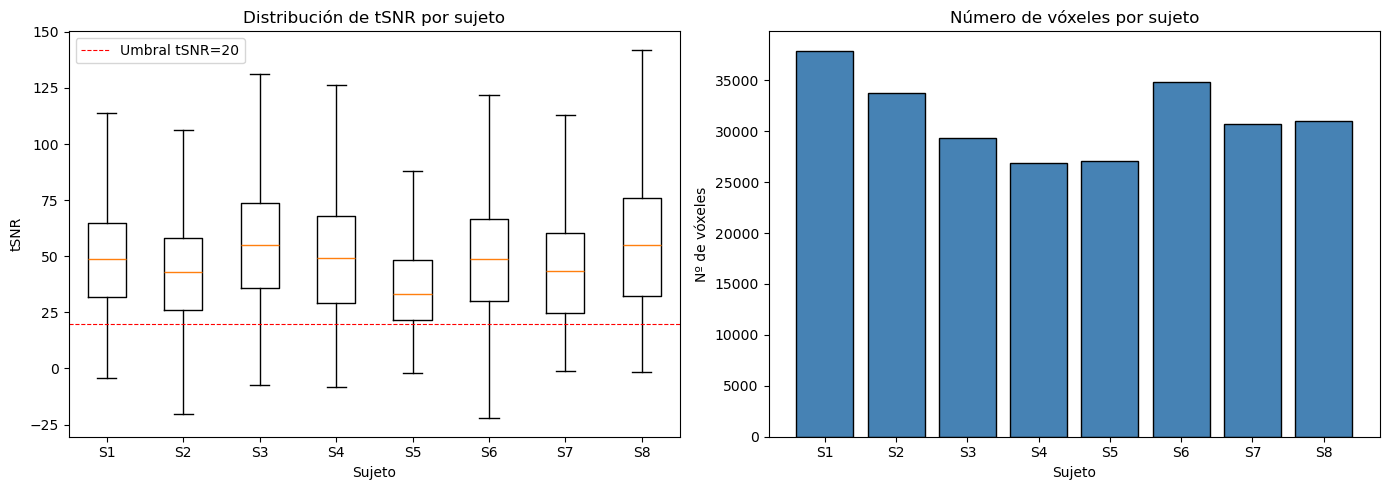

In [6]:
# Figura 1 — distribución de tSNR (boxplot) y nº de vóxeles por sujeto
tsnr_por_sujeto, voxeles = [], []
for subj_id in range(1, 9):
    mat  = sio.loadmat(f'{DATA_DIR}\\subject_{subj_id}.mat', squeeze_me=True)
    data = mat['data']
    tsnr_por_sujeto.append(data.mean(axis=0) / (data.std(axis=0) + 1e-10))
    voxeles.append(data.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(tsnr_por_sujeto, labels=[f'S{j}' for j in range(1, 9)], showfliers=False)
axes[0].axhline(20, color='red', ls='--', lw=0.8, label='Umbral tSNR=20')
axes[0].set(xlabel='Sujeto', ylabel='tSNR', title='Distribución de tSNR por sujeto')
axes[0].legend()
axes[1].bar([f'S{j}' for j in range(1, 9)], voxeles, color='steelblue', edgecolor='black')
axes[1].set(xlabel='Sujeto', ylabel='Nº de vóxeles', title='Número de vóxeles por sujeto')
plt.tight_layout(); plt.savefig('fig_tsnr_voxeles.png', dpi=150); plt.show()

Se examina e identifican las características de cada sujeto, y se comprueba que cada sujeto tiene un número diferente de vóxeles. Esto se debe a la morfología cortical de cada cerebro, diferente incluso cuando los datos se han normalizado. El resto de datos, sin embargo, coinciden.

- meta.colToCoord permite alinear vóxeles entre sujetos.

El tSNR (media temporal / desviación estándar temporal de cada vóxel) mide la calidad de la señal. Vóxeles con tSNR < 20 están dominados por ruido. Según los resultados, todos los sujetos son aptos para seguir con el análisis. Comprobamos que han sido normalizados.

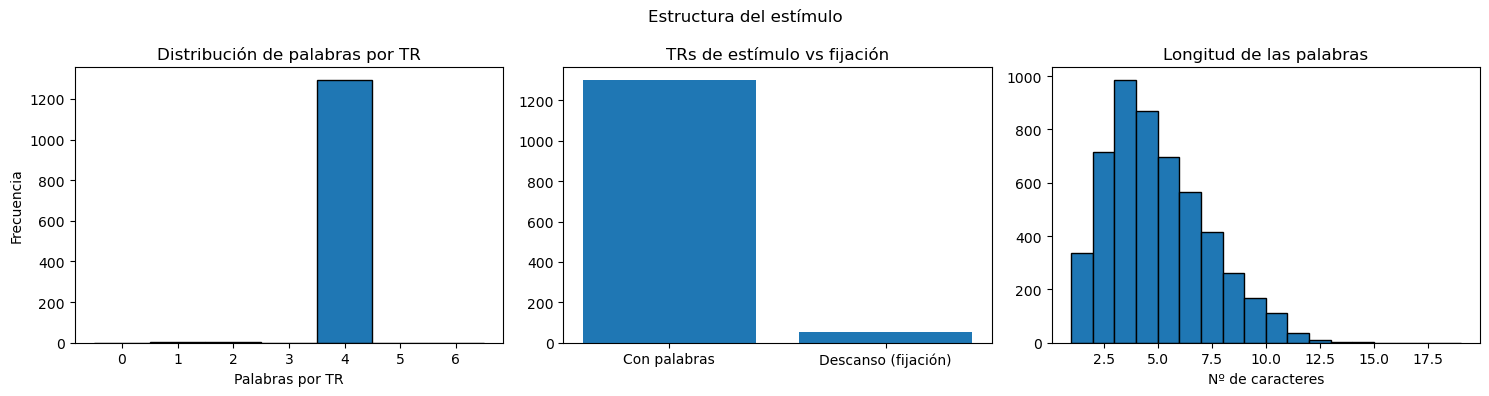

Total palabras: 5176
Total TRs: 1351
TRs con estímulo: 1299
TRs de fijación: 52
Palabras/TR — media: 4.0, rango: 1-4


In [21]:
mat = sio.loadmat(f'C:\\Users\\Ale\\Desktop\\TFM\\subject_1.mat', squeeze_me=True)
words = mat['words']
time_info = mat['time']

word_texts = [w['text'] for w in words]
word_starts = np.array([w['start'] for w in words])
time_fmri = time_info[:, 0]
runs = time_info[:, 1].astype(int)

# Asignar cada palabra al TR correspondiente
word_to_tr = np.searchsorted(time_fmri, word_starts) - 1
word_to_tr = np.clip(word_to_tr, 0, len(time_fmri) - 1)

# Contar palabras por TR
from collections import Counter
wpt = Counter(word_to_tr)

# TRs con y sin palabras
trs_with_words = set(word_to_tr)
trs_without = [t for t in range(len(time_fmri)) if t not in trs_with_words]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(list(wpt.values()), bins=range(0, 8), align='left', edgecolor='black')
axes[0].set_xlabel('Palabras por TR')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de palabras por TR')

axes[1].bar(['Con palabras', 'Descanso (fijación)'],
            [len(trs_with_words), len(trs_without)])
axes[1].set_title(f'TRs de estímulo vs fijación')

word_lengths = [len(w) for w in word_texts]
axes[2].hist(word_lengths, bins=range(1, 20), edgecolor='black')
axes[2].set_xlabel('Nº de caracteres')
axes[2].set_title('Longitud de las palabras')

plt.suptitle('Estructura del estímulo')
plt.tight_layout()
plt.savefig('qc_stimulus_structure.png', dpi=150)
plt.show()

print(f"Total palabras: {len(word_texts)}")
print(f"Total TRs: {len(time_fmri)}")
print(f"TRs con estímulo: {len(trs_with_words)}")
print(f"TRs de fijación: {len(trs_without)}")
print(f"Palabras/TR — media: {np.mean(list(wpt.values())):.1f}, "
      f"rango: {min(wpt.values())}-{max(wpt.values())}")

Estos gráficos, utilizando un sujeto de ejemplo, muestran la estructura del estímulo. Se confirma que en la gran mayoría de casos se leyeron 4 palabras por bloque de tiempo (2 segundos), y se observa un dato importante: no todos los TR deben formar parte del procesamiento en la fase 1. Pues antes de la lectura en cada bloque, los sujetos miraron una cruz durante 20 segundos.

In [7]:
# Tabla — Caracterización del estímulo lingüístico
word_texts = [str(w['text']) for w in words]
longitudes = np.array([len(w) for w in word_texts])
vocab      = set(w.lower() for w in word_texts)
wpt        = np.array(list(Counter(word_to_tr).values()))   # palabras por TR (con estímulo)

n_trs_total = len(time_fmri)
trs_estim   = len(set(word_to_tr))
trs_fijac   = n_trs_total - trs_estim

def desc(x):
    return (f"media={np.mean(x):.2f}, DE={np.std(x):.2f}, "
            f"mediana={np.median(x):.0f}, rango=[{np.min(x)}, {np.max(x)}]")

print(f"Nº total de palabras: {len(word_texts)}")
print(f"Vocabulario único: {len(vocab)}  |  ratio type/token: {len(vocab)/len(word_texts):.3f}")
print(f"Longitud de palabra (caracteres): {desc(longitudes)}")
print(f"Palabras por TR: {desc(wpt)}, moda={Counter(wpt).most_common(1)[0][0]}")
print(f"TRs totales: {n_trs_total}")
print(f"  con estímulo: {trs_estim} ({100*trs_estim/n_trs_total:.1f}%)")
print(f"  de fijación:  {trs_fijac} ({100*trs_fijac/n_trs_total:.1f}%)")

Nº total de palabras: 5176
Vocabulario único: 1778  |  ratio type/token: 0.344
Longitud de palabra (caracteres): media=4.51, DE=2.31, mediana=4, rango=[1, 14]
Palabras por TR: media=3.98, DE=0.20, mediana=4, rango=[1, 4], moda=4
TRs totales: 1351
  con estímulo: 1299 (96.2%)
  de fijación:  52 (3.8%)


In [8]:
# Tabla D — Cobertura anatómica (atlas AAL)  
def unwrap(x):+
    while isinstance(x, np.ndarray) and x.size == 1:
        x = x.item()
    return x

mat       = sio.loadmat(f'{DATA_DIR}\\subject_1.mat', squeeze_me=True)
meta      = mat['meta']
roi_names = np.array(unwrap(meta['ROInumToName']), dtype=object)
col_to_roi = np.array(unwrap(meta['colToROInum'])).astype(int)
roi_counts = Counter(col_to_roi[col_to_roi > 0])            # 0 = fuera de ROI

# Vóxeles comunes a los 8 sujetos (intersección de coordenadas)
coords_sets = []
for subj_id in range(1, 9):
    m = sio.loadmat(f'{DATA_DIR}\\subject_{subj_id}.mat', squeeze_me=True)
    coords_sets.append(set(map(tuple, np.array(unwrap(m['meta']['colToCoord'])))))
comunes = set.intersection(*coords_sets)

print(f"Nº de ROIs en el atlas (AAL): {len(roi_names)}")
print(f"Vóxeles dentro de alguna ROI (sujeto 1): {sum(roi_counts.values())}")
print(f"Vóxeles comunes a los 8 sujetos: {len(comunes)}")
print("\nROIs con más vóxeles (sujeto 1):")
for roi_id, c in roi_counts.most_common(10):
    print(f"  {roi_names[int(roi_id)-1]}: {c}")

Nº de ROIs en el atlas (AAL): 117
Vóxeles dentro de alguna ROI (sujeto 1): 37913
Vóxeles comunes a los 8 sujetos: 15371

ROIs con más vóxeles (sujeto 1):
  Temporal_Mid_L: 1365
  Temporal_Mid_R: 1110
  Temporal_Inf_R: 974
  Postcentral_L: 944
  Occipital_Mid_L: 903
  Temporal_Inf_L: 890
  Frontal_Mid_L: 864
  Precentral_L: 849
  Temporal_Sup_R: 813
  Precuneus_R: 810


Esta celda describe la organización anatómica de los datos usando el atlas AAL
(Automated Anatomical Labeling), que asigna cada vóxel a una región cerebral con
nombre. Para el sujeto 1 se cuenta cuántos vóxeles caen en cada región y se listan
las diez con más vóxeles; además se calcula cuántos vóxeles son comunes a los ocho
sujetos, intersecando sus coordenadas espaciales (`colToCoord`). La función
`unwrap` solo sirve para desempaquetar los campos del `.mat`, que vienen envueltos
en varias capas de array.

Los resultados dejan tres ideas. El atlas etiqueta 117 regiones, y todos los
vóxeles del sujeto quedan dentro de alguna de ellas. De los vóxeles de cada
sujeto, 15.371 son comunes a los ocho una vez alineados en el mismo espacio: ese
es el conjunto compartido sobre el que después se aplica la selección por ISC para
quedarse con los 10.000 vóxeles más consistentes. Y las regiones con más vóxeles
son sobre todo temporales (asociadas al lenguaje), occipitales (visión) y
pre/postcentrales (motoras y somatosensoriales), un reparto coherente con una
tarea de lectura visual, en la que intervienen tanto el procesamiento visual de
las palabras como las áreas de lenguaje.

@article{wehbe2014,
  title={Simultaneously uncovering the patterns of brain regions involved in different story reading subprocesses},
  author={Wehbe, Leila and Murphy, Brian and Talukdar, Partha and Fyshe, Alona and Ramdas, Aaditya and Mitchell, Tom},
  journal={in press},
  year={2014}
}